In [1]:
# SVM algorithm from scratch using Python and Numpy
# SVM algorithm will be implemented in a single class
class SVM:
    def __init__(self, learning_rate = 1e-3, lambda_param = 1e-2, n_iters = 1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def _init_weights_bias(self, X):
        n_features = X.shape[1]
        self.w = np.zeros(n_features)
        self.b = 0

    def _get_cls_map(self, y):
        # if y = 0 then map to -1
        return np.where(y <= 0, -1, 1)

    def _satisfy_constraint(self, x, idx):
        linear_model = np.dot(x, self.w) + self.b
        return self.cls_map[idx] * linear_model >= 1

    def _get_gradients(self, constrain, x, idx):
        # if data point lies on the correct side
        if constrain:
            dw = self.lambda_param * self.w
            db = 0
            return dw, db

        # if data point is on the wrong side
        dw = self.lambda_param * self.w - np.dot(self.cls_map[idx], x)
        db = -self.cls_map[idx]
        return dw, db

    def _update_weights_bias(self, dw, db):
        self.w -= self.lr * dw
        self.b -= self.lr * db

    def fit(self, X, y):
        self._init_weights_bias(X)
        self.cls_map = self._get_cls_map(y)

        for _ in range(self.n_iters):
            for idx, x in enumerate(X):
                # check if data point satisfies the constraint
                constrain = self._satisfy_constraint(x, idx)

                # compute the gradients accordingly
                dw, db = self._get_gradients(constrain, x, idx)

                # update weights and biases
                self._update_weights_bias(dw, db)

    def predict(self, X):
        estimate = np.dot(X, self.w) + self.b

        # compute the sign
        prediction = np.sign(estimate)

        # map class to original values {0, 1}
        return np.where(prediction == -1, 0, 1)


In [2]:
# testing the SVM classifier
# import necessary libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets

# generate synthetic dataset
X, y = datasets.make_blobs(n_samples = 1000, n_features = 2, centers = 2, cluster_std = 1.05, random_state = 1)

# split synthetic dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, random_state = 1)

# instance creation of the custom SVM classifier
clf = SVM(n_iters = 1000)

# train 'clf' classifier
clf.fit(X_train, y_train)

# predictions production
preds = clf.predict(X_test)

# function definition for computation of classification accuracy
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

print("SVM classifier accuracy:", accuracy(y_test, preds))


SVM classifier accuracy: 1.0


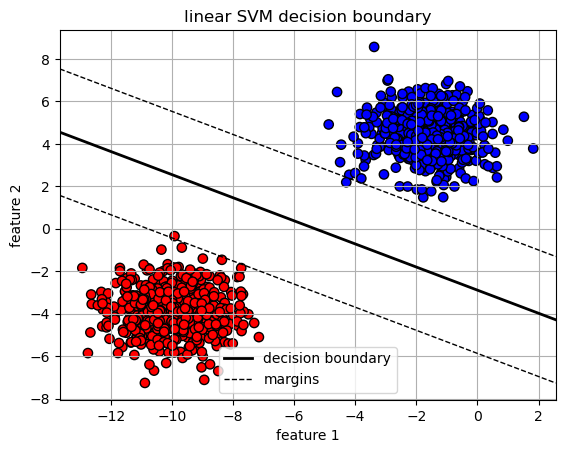

In [3]:
# visualization of the trained algorithm's classification
# import library
import matplotlib.pyplot as plt

# function definition for visualization
def plot_decision_boundary(clf, X, y):
    """
    Plot dataset together with decision boundary and two margin lines
    """

    plt.figure()

    # plot data points
    plt.scatter(X[:, 0], X[:, 1], c = y, cmap = "bwr", edgecolors = "k", s = 45)

    ax = plt.gca()

    # current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid
    xx = np.linspace(xlim[0], xlim[1], 100)

    # decision boundary
    yy = -(clf.w[0] * xx + clf.b) / clf.w[1]

    # margin lines
    yy_down = -(clf.w[0] * xx + clf.b - 1) / clf.w[1]
    yy_up = -(clf.w[0] * xx + clf.b + 1) / clf.w[1]

    # plot decision boundary
    plt.plot(xx, yy, "k-", linewidth = 2, label = "decision boundary")

    # plot margins
    plt.plot(xx, yy_down, "k--", linewidth = 1, label = "margins")
    plt.plot(xx, yy_up, "k--", linewidth = 1)
    
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title("linear SVM decision boundary")
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.legend()
    plt.grid()
    plt.show()


# plot SVM classifier together with the entire dataset
plot_decision_boundary(clf, X, y)
